True


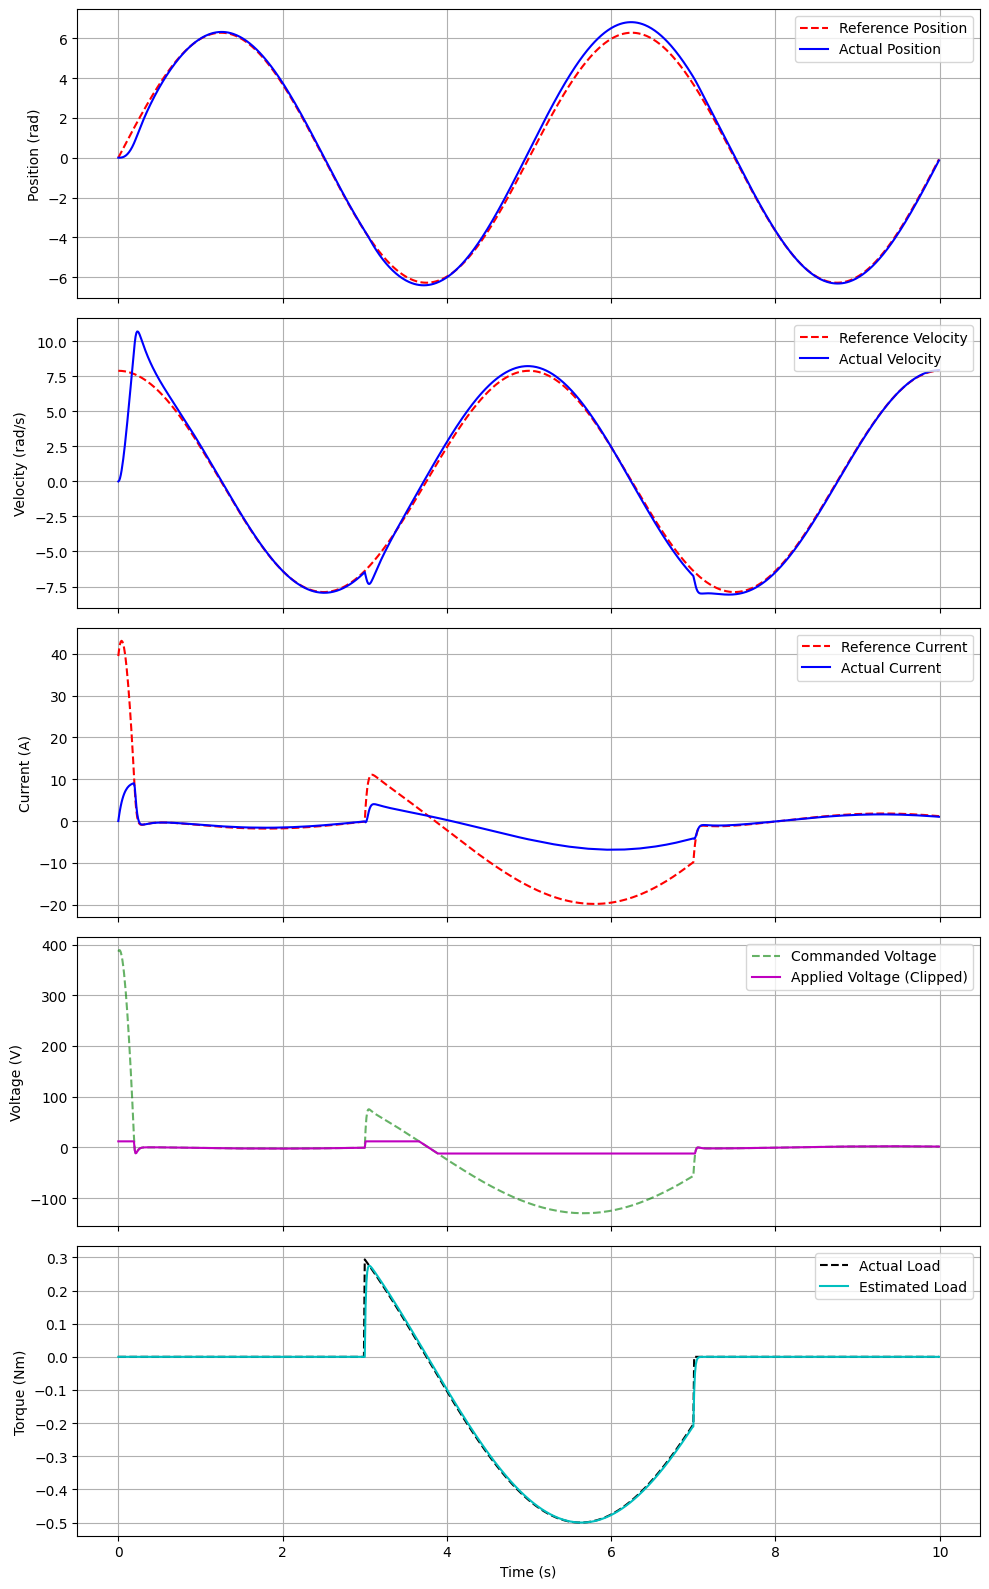

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as sci_int

parameters = {
    'Ra': 1.2,
    'La': 0.08,
    'Kt_nominal': 0.08,
    'Kb_nominal': 0.08,
    'Jm_nominal': 0.01,
    'Bf_nominal': 0.01,
    'Jm': 0.01,
    'Bf': 0.01,
    'Kt': 0.08,
    'Kb': 0.08,
    'V_max': 12,
    'T_max': 1.5,
    'Omega_max': 4.71,
    'Theta_amp': 360 * (np.pi / 180),
    'Theta_freq': 0.2,
    'Tload': 0,
    'Omega_amp': 1 * (2 * np.pi * 0.2),
    'x0': [0.0, 0.0, 0.0, 0.0, 0.0],
    'startTime': 0,
    'endTime': 10,
    'dt': 0.01,
    't_eval': np.arange(0, 5, 0.01),
    'LoadStart': 3,
    'LoadEnd': 7,
    'Kp_position': 2,
    'Kd_velocity': 0.4,
    'Kp_current': 11,
    'Kd_current': 0.01,
    'omega_f': 75
}

J_hat = parameters['Jm_nominal']
B_hat = parameters['Bf_nominal']
Kt_hat = parameters['Kt_nominal']
omega_f = parameters['omega_f']
    
Theta_amp = parameters['Theta_amp']
Theta_freq = parameters['Theta_freq']
LoadStart = parameters['LoadStart']
LoadEnd = parameters['LoadEnd']

Ra = parameters['Ra']
La = parameters['La']
Jm = parameters['Jm']
Bf = parameters['Bf']
Kt = parameters['Kt']
Kb = parameters['Kb']

# Simulation
t_eval = np.arange(parameters['startTime'], parameters['endTime'], parameters['dt'])

#describing the state space

A = np.array([
    [-Ra/La,  0, -Kb/La],
    [     0,  0,      1],
    [ Kt/Jm,  0, -Bf/Jm]
])

B = np.array([
    [1/La,     0],
    [   0,     0],
    [   0, -1/Jm]
])

C = np.array([
    [0,1,0],
    [0,0,1]
])

# describing the plant 
x0 = [0,0,0,0,0]
def motor_plant(t,x):
    I = x[0]
    Theta = x[1]
    Omega = x[2]

    # for filters

    x_i = x[3]
    x_w = x[4]

    # describng the references

    Theta_ref = Theta_amp * np.sin(2 * np.pi * Theta_freq * t)
    Omega_ref_ff = Theta_amp * 2 * np.pi * Theta_freq * np.cos(2 * np.pi * Theta_freq * t)

    # error in theta 
    error_theta = Theta_ref - Theta

    # differential error in omega 
    error_omega = Omega_ref_ff - Omega

    # Applying the load profile 

    if t >= LoadStart and t <= LoadEnd:
        Tload = 0.5 * np.sin((2*np.pi*0.05 + (30* np.pi / 180))*t)
    else :
        Tload = 0

    # Estimating the Load as a disturbance

    #Continuous-time filter derivatives: dx/dt = omega_f * (u - x)
    dx_i = omega_f * (I - x_i) 
    dx_w = omega_f * (Omega - x_w)

    # This below one is used when considered discrete 
    # # filter - 
    # alpha = 1 - np.e**(-omega_f)
    # dx_i = alpha * I + (1 - alpha) * x_i #results in filter output
    # dx_w = alpha * Omega + (1 - alpha) * x_w #results in filtered output

    #Defining the obserbver outcomes
    Telec = Kt_hat * x_i
    Tmech = (B_hat * x_w) + (J_hat * omega_f * (Omega - x_w))
    Tload_hat = Tmech - Telec

    T_cmd = (parameters['Kp_position'] * error_theta) + (parameters['Kd_velocity'] * error_omega) + Tload_hat
    I_ref = T_cmd / Kt_hat

    error_current = I_ref - I

    #mapping the voltage 

    numerator = (parameters['Kp_current'] * error_current) + (parameters['Kd_current'] / La) * (Ra * I + Kb * Omega)
    denominator = 1 + (parameters['Kd_current'] / La)
    V_cmd = numerator / denominator

    V_app = np.clip(V_cmd, -parameters['V_max'], parameters['V_max'])

    u = np.array([V_app, Tload])
    dx = A.dot(x[0:3]) + B.dot(u) 

    dx_full = [dx[0], dx[1], dx[2], dx_i, dx_w]

    return dx_full

solution = sci_int.solve_ivp(
    motor_plant,
    t_eval=t_eval,
    t_span=(parameters['startTime'], parameters['endTime']),
    y0=x0
)

print(solution.success)

def plot_motor_simulation(solution, parameters):
    t = solution.t
    I_actual = solution.y[0]
    Theta_actual = solution.y[1]
    Omega_actual = solution.y[2]
    x_i = solution.y[3]
    x_w = solution.y[4]

    Theta_ref = parameters['Theta_amp'] * np.sin(2 * np.pi * parameters['Theta_freq'] * t)
    Omega_ref = parameters['Theta_amp'] * 2 * np.pi * parameters['Theta_freq'] * np.cos(2 * np.pi * parameters['Theta_freq'] * t)

    Tload_actual = np.where(
        (t >= parameters['LoadStart']) & (t <= parameters['LoadEnd']), 
        0.5 * np.sin((2 * np.pi * 0.05 + (30 * np.pi / 180)) * t), 
        0
    )

    # CORRECTED observer outcomes in the plot reconstruction
    Telec = parameters['Kt_nominal'] * x_i
    Tmech = (parameters['Bf_nominal'] * x_w) + \
            (parameters['Jm_nominal'] * parameters['omega_f'] * (Omega_actual - x_w))
    
    Tload_hat = Telec - Tmech # CORRECTED SIGN

    T_cmd = (parameters['Kp_position'] * (Theta_ref - Theta_actual)) + \
            (parameters['Kd_velocity'] * (Omega_ref - Omega_actual)) + Tload_hat

    I_ref = T_cmd / parameters['Kt_nominal']

    error_current = I_ref - I_actual
    numerator = (parameters['Kp_current'] * error_current) + \
                (parameters['Kd_current'] / parameters['La']) * \
                (parameters['Ra'] * I_actual + parameters['Kb'] * Omega_actual)
    denominator = 1 + (parameters['Kd_current'] / parameters['La'])
    
    V_cmd = numerator / denominator
    V_app = np.clip(V_cmd, -parameters['V_max'], parameters['V_max'])

    fig, axs = plt.subplots(5, 1, figsize=(10, 16), sharex=True)

    axs[0].plot(t, Theta_ref, 'r--', label='Reference Position')
    axs[0].plot(t, Theta_actual, 'b-', label='Actual Position')
    axs[0].set_ylabel('Position (rad)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    axs[1].plot(t, Omega_ref, 'r--', label='Reference Velocity')
    axs[1].plot(t, Omega_actual, 'b-', label='Actual Velocity')
    axs[1].set_ylabel('Velocity (rad/s)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    axs[2].plot(t, I_ref, 'r--', label='Reference Current')
    axs[2].plot(t, I_actual, 'b-', label='Actual Current')
    axs[2].set_ylabel('Current (A)')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    axs[3].plot(t, V_cmd, 'g--', alpha=0.6, label='Commanded Voltage')
    axs[3].plot(t, V_app, 'm-', label='Applied Voltage (Clipped)')
    axs[3].set_ylabel('Voltage (V)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)

    axs[4].plot(t, Tload_actual, 'k--', label='Actual Load')
    axs[4].plot(t, Tload_hat, 'c-', label='Estimated Load')
    axs[4].set_xlabel('Time (s)')
    axs[4].set_ylabel('Torque (Nm)')
    axs[4].legend(loc='upper right')
    axs[4].grid(True)

    plt.tight_layout()
    plt.show()

plot_motor_simulation(solution,parameters)